In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
import sympy as sp

from ortools.linear_solver import pywraplp
from IPython.display import display, Markdown

def md(title, body):
    """
    계산 결과를 Markdown 형식으로 출력하는 보조함수.

    title : 해석 블록의 제목
    body  : 분석 결과에 대한 자연어 설명
    """
    
    display(
        Markdown(
            f"### {title}\n\n{body}"
        )
    )

STATUS_LABEL = {
    pywraplp.Solver.OPTIMAL: "OPTIMAL",
    pywraplp.Solver.FEASIBLE: "FEASIBLE",
    pywraplp.Solver.INFEASIBLE: "INFEASIBLE",
    pywraplp.Solver.UNBOUNDED: "UNBOUNDED",
    pywraplp.Solver.NOT_SOLVED: "NOT_SOLVED",
}


md(
    "환경 설정 완료",
    "이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다."
)


plt.rcParams["axes.unicode_minus"] = False

HUMAN_CAP = 80
TOKEN_CAP = 100
PROFIT_TARGET = 210

print("STEP2 환경설정 완료")

### 환경 설정 완료

이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다.

STEP2 환경설정 완료


# STEP 2 — Standard Form, Basis, Basic Feasible Solution

STEP 1에서는 다음 Human Business Model의 Feasibility를 확인했다.

이번에는 시각화를 위해 네 상품 중 두 개만 사용하는
2차원 Mini Model을 만든다.

$$
x = P0\text{ Product MVP 수}
$$

$$
y = P3\text{ Full Package 수}
$$

단, Simplex의 기하학을 공부하기 위해
이번 단계에서는 x와 y를 연속형 변수라고 가정한다.

$$
x,y\ge0
$$

---

## 상품별 값

| 항목 | P0 | P3 |
|---|---:|---:|
| 공헌이익 | 20 | 100 |
| Human Time | 6 | 28 |
| AI Token | 6 | 42 |

Token 단위는

$$
1U=10,000\text{ tokens}
$$

이다.

---

## 제약조건

### Human Capacity

$$
6x+28y\le80
$$

### AI Token Capacity

$$
6x+42y\le100
$$

### 최소 Profit 목표

$$
20x+100y\ge210
$$

### Non-negativity

$$
x,y\ge0
$$

---

## STEP 2의 질문

지금부터는 Solver가 답을 주는 것을 보는 것이 아니라,

1. 왜 부등식을 등식으로 바꾸는가?
2. Slack / Surplus는 무엇인가?
3. Artificial Variable은 왜 필요한가?
4. Basis란 무엇인가?
5. Basic Solution은 어떻게 계산하는가?
6. Basic Feasible Solution과 그래프의 꼭짓점은 왜 같은가?

를 직접 코드로 확인한다.

# 2-1. Slack Variable

첫 번째 제약조건은

$$
6x+28y\le80
$$

이다.

현재 x,y가 사용한 Human Time은

$$
6x+28y
$$

이고 전체 Capacity는 80이다.

따라서 남은 시간은

$$
80-(6x+28y)
$$

이다.

이 남은 양을 새로운 변수

$$
s_H\ge0
$$

로 정의한다.

그러면

$$
\boxed{
6x+28y+s_H=80
}
$$

이 된다.

즉 Slack Variable은

$$
\boxed{
s_H=\text{사용하지 않고 남은 자원}
}
$$

이다.

부등식을 등식으로 바꾸었지만
원래 문제의 의미는 변하지 않았다.

In [2]:
x_sample = 1
#productMVP를 1건으로 가정

y_sample = 2
#fullPACKAGE를 2건이라 가정

human_used = (
    6 * x_sample 
    + 28 * y_sample
)
#실제 사용 human time계산

human_slack = (
    HUMAN_CAP 
    - human_used
)
#전체 capa에서 human used 즉 80에서 실 사용시간을 뺀다

print("P0 =", x_sample)
print("P3 =", y_sample)

print("사용 human time = ", human_used)
print("human slack", human_slack)

#등식이 정말 성립하는지도 확인

left_side = (
    6 * x_sample
    + 28 * y_sample
    + human_slack 
)

print("6x + 28y + s_H =", left_side)
print("Right-hand side =", HUMAN_CAP)

P0 = 1
P3 = 2
사용 human time =  62
human slack 18
6x + 28y + s_H = 80
Right-hand side = 80


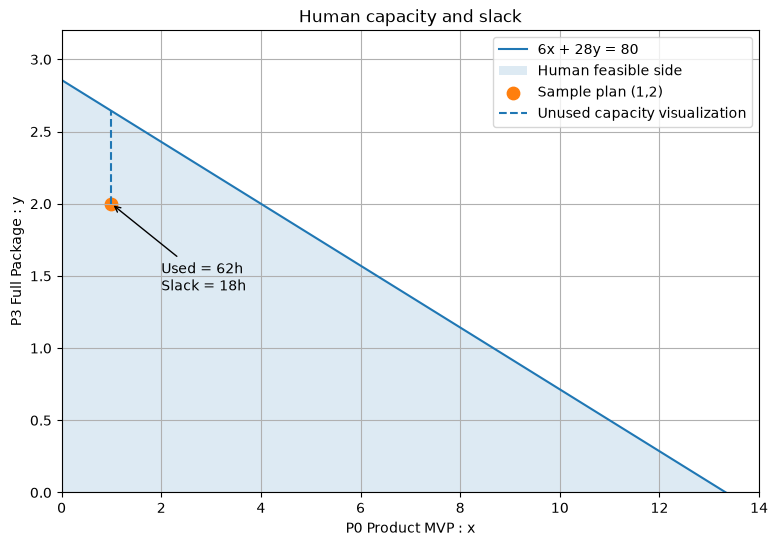

In [3]:
#Human Constraint와 Slack 시각화


# x축에서 P0 프로젝트 수를 0~14까지 연속적으로 만든다.
x_grid = np.linspace(0, 14, 400)


# 경계식:
#
# 6x + 28y = 80
#
# 를 y에 대해 풀면
#
# y = (80 - 6x) / 28

human_boundary = (
    HUMAN_CAP
    - 6 * x_grid
) / 28


# y가 음수가 되는 부분은
# 현실적인 non-negative 영역 밖이므로
# 그림에서는 0 이상인 부분만 사용한다.
human_boundary_positive = np.maximum(
    human_boundary,
    0
)


plt.figure(figsize=(9, 6))


# Human Capacity의 경계선을 그린다.
plt.plot(
    x_grid,
    human_boundary,
    label="6x + 28y = 80"
)


# 경계선 아래가
# 6x + 28y <= 80
# 을 만족하는 영역이다.
plt.fill_between(
    x_grid,
    0,
    human_boundary_positive,
    alpha=0.15,
    label="Human feasible side"
)


# 우리가 선택한 점 (1,2)를 표시한다.
plt.scatter(
    x_sample,
    y_sample,
    s=80,
    label="Sample plan (1,2)"
)


# x=1일 때 Human Capacity 경계선의 y값을 계산한다.
y_on_human_boundary = (
    HUMAN_CAP
    - 6 * x_sample
) / 28


# 현재 점에서 경계까지 수직선을 그린다.
plt.vlines(
    x_sample,
    y_sample,
    y_on_human_boundary,
    linestyles="--",
    label="Unused capacity visualization"
)


# 현재 점의 위치를 텍스트로 표시한다.
plt.annotate(
    f"Used = {human_used}h\nSlack = {human_slack}h",
    xy=(x_sample, y_sample),
    xytext=(2.0, 1.4),
    arrowprops={"arrowstyle": "->"}
)


plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Human capacity and slack")

plt.xlim(0, 14)
plt.ylim(0, 3.2)

plt.grid(True)
plt.legend()
plt.show()

여기서 주의.

그림에서 점과 선 사이의 수직거리 자체가 18시간인 것은 아니다.

수직 gap은:

$$ \Delta y = \frac{18}{28} $$

이다.

왜냐하면 P3 한 단위 증가가 Human Time을 28시간 사용하기 때문이다.

즉:

$$ 28\Delta y=s_H. $$

이 distinction을 잡아야 한다

# 2-2. Surplus Variable

이번에는 Profit 목표를 보자.

$$
20x+100y\ge210
$$

이 경우에는 목표보다 많이 벌 수 있다.

실제 Profit이 210보다 얼마나 초과했는지를

$$
s_P\ge0
$$

라고 정의한다.

그러면

$$
\boxed{
20x+100y-s_P=210
}
$$

이다.

왜 더하는 것이 아니라 빼는가?

실제 Profit이 220이라면

$$
220-s_P=210
$$

이어야 하므로

$$
s_P=10
$$

이어야 하기 때문이다.

따라서

$$
\boxed{
s_P=\text{목표를 초과한 양}
}
$$

이다.

Slack과 Surplus는 방향이 다르다.

$$
\le \quad\Rightarrow\quad +Slack
$$

$$
\ge \quad\Rightarrow\quad -Surplus
$$

Actual Profit = 220
Profit Target = 210
Profit Surplus = 10


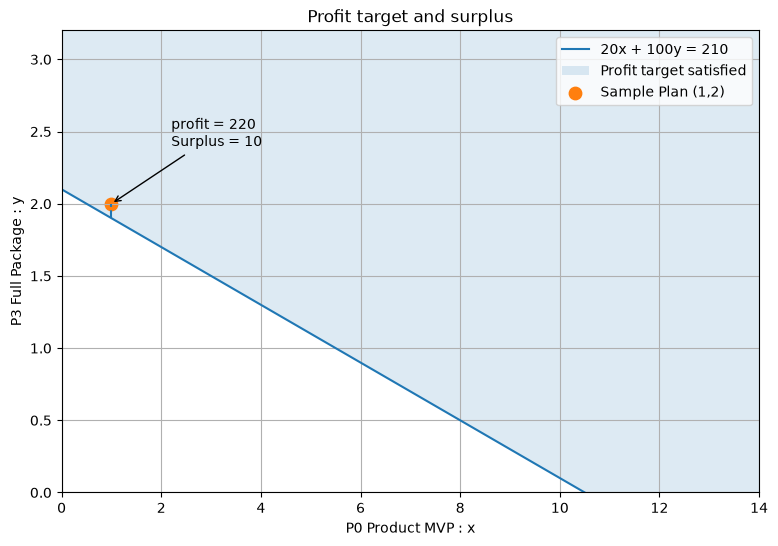

In [4]:
profit_actual = (
    20 * x_sample
    + 100 * y_sample
)
# x,y = 1,2 의 실제 profit

profit_surplus = (
    profit_actual
    - PROFIT_TARGET
)
#목표보다 즉 210보다 얼마나 벌었는지.

print("Actual Profit =", profit_actual)
print("Profit Target =", PROFIT_TARGET)
print("Profit Surplus =", profit_surplus)

# Profit 목표 경계선 시각화
# -------------------------------------------

profit_boundary = (
    PROFIT_TARGET
    - 20 * x_grid
) / 100
# 20x + 100y = 210에 대해서 y에 대해 푼것.

plt.figure(figsize=(9,6))
plt.plot(
    x_grid,
    profit_boundary,
    label="20x + 100y = 210"
)
#profit은 >= 210이므로 경계선 위쪽이 목표를 만족하는 영역이다.

plt.fill_between(
    x_grid,
    np.maximum(profit_boundary, 0),
    3.2,
    alpha=0.15,
    label="Profit target satisfied"
)

plt.scatter(
    x_sample,
    y_sample,
    s=80,
    label="Sample Plan (1,2)"
)

#x=1에서 목표 pfofit을 210을 정확히 만드는 y값
y_on_human_boundary = (
    PROFIT_TARGET
    - 20 * x_sample
) / 100

plt.vlines(
    x_sample,
    y_on_human_boundary,
    y_sample,
    linestyles="--"

)

plt.annotate(
    f"profit = {profit_actual}\nSurplus = {profit_surplus}",
    xy=(x_sample, y_sample),
    xytext=(2.2, 2.4),
    arrowprops={"arrowstyle": "->"}
)


plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Profit target and surplus")

plt.xlim(0, 14)
plt.ylim(0, 3.2)

plt.grid(True)
plt.legend()
plt.show()

# 왜 Artificial Variable이 필요한가?

# 2-3. Artificial Variable

Profit 제약은

$$
20x+100y\ge210
$$

이었다.

Surplus를 빼서

$$
20x+100y-s_P=210
$$

으로 만들었다.

그런데 Simplex의 출발점으로

$$
x=0,\qquad y=0
$$

을 생각해보자.

그러면

$$
-s_P=210
$$

이다.

따라서

$$
s_P=-210
$$

이 필요한데,

$$
s_P\ge0
$$

이어야 하므로 불가능하다.

즉 단순히 Surplus Variable만 넣어서는
초기 Basic Feasible Solution을 만들기 어렵다.

그래서 계산을 시작하기 위한 임시 변수

$$
a_P\ge0
$$

를 추가한다.

$$
\boxed{
20x+100y-s_P+a_P=210
}
$$

이제 x=y=s_P=0이라고 하면

$$
a_P=210
$$

으로 등식을 만족시킬 수 있다.

---

## Artificial Variable의 의미

Artificial Variable은 현실의 자원이 아니다.

돈도 아니다.
시간도 아니다.
프로젝트도 아니다.

Simplex가 출발할 수 있도록
임시 Basis column을 만드는 계산용 변수다.

따라서 최종적으로는 반드시

$$
\boxed{a_P=0}
$$

으로 제거되어야 한다.

Phase I에서는

$$
\min a_P
$$

를 수행한다.

최솟값이 0이면 원래 문제가 feasible하다.

0보다 크게 남으면 원래 문제에는 feasible solution이 없다.

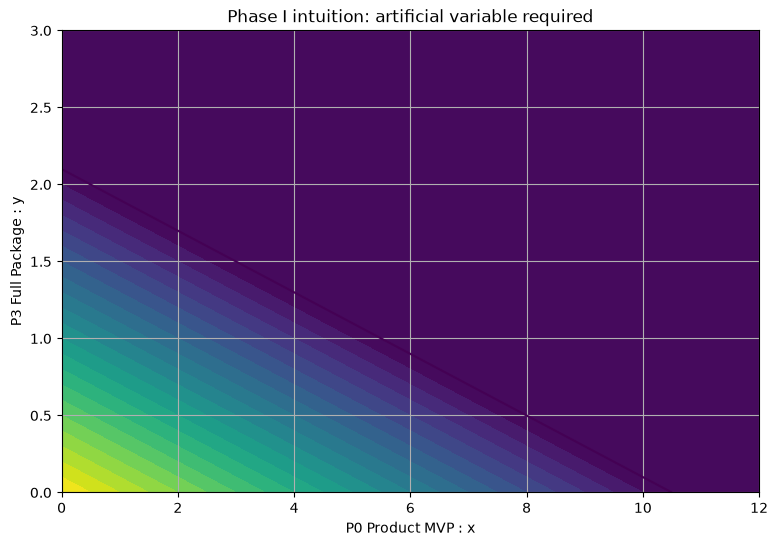

### Profit이 낮은 영역: $$ a_P>0. $$, Profit target을 넘어가면: $$ a_P=0. $$

즉 Phase I은 일종의 “Artificial 높이가 0인 원래 feasible 공간까지 내려가는 과정”으로 볼 수 있다.

None


In [5]:
# 각 (x,y)에서 필요한 최소 Artificial Variable 계산


# 2차원 grid를 만든다.
x_values = np.linspace(0, 12, 200)
y_values = np.linspace(0, 3, 200)

X, Y = np.meshgrid(
    x_values,
    y_values
)
# X, Y 모든 (X,Y) 조합이 GRID 형태로 저장될 수 있도록한다.

profit_grid = (
    20 * X
    + 100 * Y
)
# GRID의 모든 점에서 PROFIT을 계산한다.

artificial_required = np.maximum(
    0, 
    PROFIT_TARGET - profit_grid
)
# profit이 210보다 작으면, 부족한만큼 artificial variable이 필요한데, profit >= 210일시 => artificial은 0이면 된다.

plt.figure(figsize=(9, 6))

#artificial variable은 0이면 된다.
contour = plt.contourf(
    X,
    Y,
    artificial_required,
    levels=20
)

# 이때 오른쪽 colorbar는 각 위치에서 필요한 a_p의 크기를 나타낼 수 있도록한다.
plt.contour(
    X,
    Y,
    profit_grid,
    levels=[PROFIT_TARGET]
)
plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Phase I intuition: artificial variable required")

plt.grid(True)
plt.show()

print(md("Profit이 낮은 영역: $$ a_P>0. $$, Profit target을 넘어가면: $$ a_P=0. $$", "즉 Phase I은 일종의 “Artificial 높이가 0인 원래 feasible 공간까지 내려가는 과정”으로 볼 수 있다."))


# 2-4. Standard Form

현재 세 식은 다음과 같다.

Human:

$$
6x+28y+s_H=80
$$

Token:

$$
6x+42y+s_T=100
$$

Profit:

$$
20x+100y-s_P+a_P=210
$$

변수들을 하나의 Vector로 묶자.

$$
z=
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
$$

그러면 전체 시스템은

$$
\boxed{Az=b}
$$

로 쓸 수 있다.

여기서

$$
A=
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
$$

이고

$$
b=
\begin{bmatrix}
80\\
100\\
210
\end{bmatrix}
$$

이다.

이 순간부터 matrix와 OR 문제가 완전히 합쳐진다.

Source의 표현대로:

$$ Az = z_1A_1+z_2A_2+\cdots+z_6A_6. $$

즉 A의 column들을 변수 값만큼 섞어서 \(b\)를 만드는 문제다.

$$
z=
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
=
A=
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
$$


$$
Z
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
A
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
=
B
\begin{bmatrix}
80\\
100\\
210
\end{bmatrix}
$$

In [6]:

variable_names = [
    "x_P0",
    "y_P3",
    "s_H",
    "s_T",
    "s_P",
    "a_P",
]
# A의 각 COLUMN이 의미하는 변수를 순서대로 저장한다

constraint_names = [
    "Human",
    "Token",
    "Profit",
] #A의 각 row가 의미하는 constraints

A = np.array(
    [
        [6, 28, 1, 0, 0, 0],
        [6, 42, 0, 1, 0, 0],
        [20, 100, 0, 0, -1, 1],
    ],
    dtype=float,
) # coefficient matrix A.

b = np.array(
    [
        80,
        100,
        210,
    ],
    dtype=float,
)#right-hand 우변 벡터 b

A_df = pd.DataFrame(
    A,
    index=constraint_names,
    columns=variable_names,
)

b_df = pd.DataFrame(
    {
        "b": b
    },
    index=constraint_names,
)
display(A_df)
display(b_df)

print("A shape =", A.shape)
print("b shape =", b.shape)
print("rank(A) =", np.linalg.matrix_rank(A))

print(md("여기서: $$ A.shape=(3,6) $$이다.", "즉 3개의 equation과 6개의 variable 그리고 rank는 3이다."))

,x_P0,y_P3,s_H,s_T,s_P,a_P
Human,6.0,28.0,1.0,0.0,0.0,0.0
Token,6.0,42.0,0.0,1.0,0.0,0.0
Profit,20.0,100.0,0.0,0.0,-1.0,1.0


,b
Human,80.0
Token,100.0
Profit,210.0


A shape = (3, 6)
b shape = (3,)
rank(A) = 3


### 여기서: $$ A.shape=(3,6) $$이다.

즉 3개의 equation과 6개의 variable 그리고 rank는 3이다.

None


# 행이 3개인데 왜 Basis도 3개인가

# 2-5. Basis

A에는 6개의 Column Vector가 있다.

$$
A=
[A_x,A_y,A_{s_H},A_{s_T},A_{s_P},A_{a_P}]
$$

각 column은 세 개의 component를 가지므로

$$
A_j\in\mathbb R^3
$$

이다.

현재 독립 constraint의 수는

$$
rank(A)=3
$$

이다.

따라서 하나의 Basis는
A의 column들 중

$$
\boxed{3개의 선형독립 column}
$$

을 선택해서 만든다.

선택한 세 column을 모은 행렬을

$$
B
$$

라고 한다.

그러면 Basic Variable만 남겨

$$
Bx_B=b
$$

를 푼다.

나머지 Nonbasic Variable은 0으로 둔다.

따라서

$$
\boxed{x_B=B^{-1}b}
$$

가 된다.

## 여기서 “basis”는 그냥 중요한 변수들이 아니다.

column space에서 \(b\)를 표현할 좌표축 역할을 하는 독립 column 집합이다.

initial_basis_idx ---
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

rank(B0) =
3

det(B0) =
1.0


### 결과:

즉: $$B0=I$$ 그래서 초기 basis를 만들기 아주 쉽다.

None


,Basic Variable,Value
0,s_H,80.0
1,s_T,100.0
2,a_P,210.0


### ---

따라서, $$Basic + Nonbasic$$ 을 합쳐 전체 z를 만든다.

None


,Variable,Value,Status
0,x_P0,0.0,Nonbasic
1,y_P3,0.0,Nonbasic
2,s_H,80.0,Basic
3,s_T,100.0,Basic
4,s_P,0.0,Nonbasic
5,a_P,210.0,Basic


,A @ z,Target,Difference
Human,80.0,80.0,0.0
Token,100.0,100.0,0.0
Profit,210.0,210.0,0.0


### 확장된 Phase-I 문제에서는 BFS다.

 그러나, $$aP​=210>0$$ 이므로, 따라서 아직 원 문제의 feasible point는 아니다

None


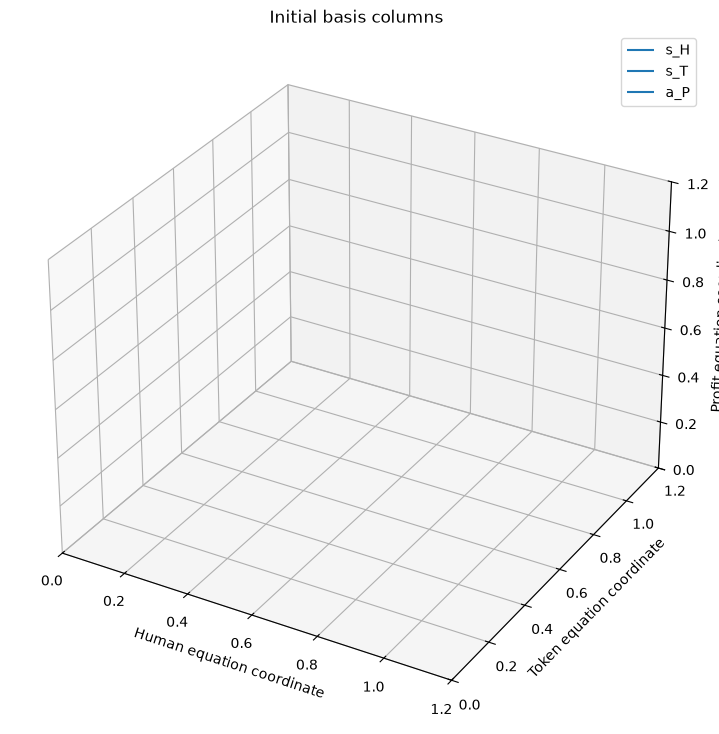

In [7]:
# 초기 basis = {s_h, s_t, a_p}

initial_basis_names = [
    "s_H",
    "s_T",
    "a_P",
] # 초기에는 두 slack과 Artificial Variables를 Basic Variables로 사용한다.

initial_basis_idx = [
    variable_names.index(name)
    for name in initial_basis_names
] # 변수 이름을 실제 A의 column index로 변환한다.

B0 = A[:, initial_basis_idx]
#A에서 해당 COLUMN만 추출

print("initial_basis_idx", "---")
print(B0)
print("\nrank(B0) =")
print(np.linalg.matrix_rank(B0))
print("\ndet(B0) =")
print(np.linalg.det(B0))

print(md("결과:", "즉: $$B0=I$$ 그래서 초기 basis를 만들기 아주 쉽다."))
x_B0 = np.linalg.solve(
    B0,
    b
)
# B0 x_B = b, 를 직접 풀 시, B0는 identity이므로 사실상 결과는 b와 같다.

initial_basis_table = pd.DataFrame(
    {
        "Basic Variable": initial_basis_names,
        "Value": x_B0,
    }
)

display(initial_basis_table)

print(md("---", "따라서, $$Basic + Nonbasic$$ 을 합쳐 전체 z를 만든다."))

z0 = np.zeros(
    len(variable_names)
) # 전체 6개 변수를 우선 0으로 만들고, 이는 곧 "NonBasic Variable은 0으로 둔다" 는 과정이다.

z0[initial_basis_idx] = x_B0
# 이때, Basic Variable 위치에만 B^-1 b 결과를 넣는다.

initial_solution = pd.DataFrame(
    {
        "Variable": variable_names, 
        "Value": z0,
        "Status": [
            "Basic" if i in initial_basis_idx 
            else "Nonbasic"
            for i in range(len(variable_names))
        ] 
    }
)
display(initial_solution)

#검증 : 
reconstructed_b = A @ z0
verification_initial_solution = pd.DataFrame(
    {
        "A @ z": reconstructed_b,
        "Target": b,
        "Difference": reconstructed_b - b,

    },
    index=constraint_names,
)
display(verification_initial_solution)

print(md("확장된 Phase-I 문제에서는 BFS다.", " 그러나, $$aP​=210>0$$ 이므로, 따라서 아직 원 문제의 feasible point는 아니다"))

# --- Initial Basis Column을 3D에서 시각화
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(
    111,
    projection="3d"
)
origin = np.zeros(3) # 세 컬럼벡터 모두 원점에서 시작할 수 있도록.

for column_index, name in zip(
    initial_basis_idx,
    initial_basis_names,
):
    vector = A[:, column_index] 
    # 현재 basis column vector


    ax.quiver(
        origin[0],
        origin[1],
        origin[2],
        origin[0],
        origin[1],
        origin[2],
        arrow_length_ratio=0.12,
        label=name,
    )

ax.set_xlabel("Human equation coordinate")
ax.set_ylabel("Token equation coordinate")
ax.set_zlabel("Profit equation coordinate")

ax.set_title("Initial basis columns")

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.set_zlim(0, 1.2)

ax.legend()
plt.show()

# 2-6. Basic Solution vs Basic Feasible Solution

Basis B를 하나 선택하면

1. Nonbasic Variable을 0으로 둔다.
2. $$
   Bx_B=b
   $$
   를 푼다.

이렇게 얻은 해가 Basic Solution이다.

하지만 Basic Variable 중 음수가 나오면

$$
x_B\not\ge0
$$

이므로 LP의 non-negativity condition을 위반한다.

따라서

$$
\boxed{
x_B\ge0
}
$$

까지 만족해야

$$
\boxed{
Basic\ Feasible\ Solution
}
$$

즉 BFS가 된다.

이제 컴퓨터로 가능한 Basis를 전부 골라보고
각각 BFS인지 직접 검사한다.

In [15]:
# 가능한 모든 Basis를 전수조사
# 모든 3column basis 후보를 직접 검사한다.

m = A.shape[0] # m=equation수 , =3 // 따라서 basis에는 3개의 column이 필요함.
n = A.shape[1] # n= 전체 variable/column수, = 6.

TOL = 1e-9 # 컴퓨터의 부동소수점을 처리하기 위한 tolerance.

basis_results = [] # 각 basis의 계산 결과를 저장하기 위함.

for basis_cols in combinations(
    range(n),
    m,
): # 6개 컬럼중 3개를 선택하는 모든 조합을 하나씩 검사한다.

    B = A[:, basis_cols] #현재 선택한 3개의 column만 뽑는다.

    rank_B = np.linalg.matrix_rank(B) #이때의 세개의 column이 정말 선혀 독립인지 확인한다.

    if rank_B < m: #이때 rank가 3보다 작으면 basis가 될 수 없다.
        continue

    x_B = np.linalg.solve(
        B,
        b
    ) # B x_B = b를 푼다.

    z = np.zeros(n) # Nonbasic Variable은 모두 0.

    z[list(basis_cols)] = x_B #BasisVariable 위치에 계산값을 넣는다.

    z[np.abs(z) < TOL] = 0 #이때 매우 작은 floating_point 값을 0으로 정리한다.

    phase1_feasible = np.all(
        z >= -TOL

    ) #모든 변수가 0 이상일시, 확장된 Phase1 문제에서는 BFS이다.

    artificial_index = variable_names.index("a_P")

    original_feasible = (
        phase1_feasible
        and abs(z[artificial_index]) <= TOL
    ) #artificial variables까지 0이면 원래 문제에서도 feasible한 BFS이다.

    basis_results.append(
        {
            "Basis": ", ".join(
                variable_names[i]
                for i in basis_cols
            ),

            "Rank": rank_B,
            "x_P0": z[0],
            "y_P3": z[1],
                
            "s_H": z[2],
            "s_T": z[3],
            "s_P": z[4],
            "a_P": z[5],
            
            "Phase1_BFS": phase1_feasible,
            "Original_BFS": original_feasible,

        }
    )

basis_df = pd.DataFrame(
    basis_results
)

display(basis_df)

print(md("OR-Tools가 Basis를 내부적으로 고르는 걸 그냥 믿는 게 아니라 우리가 직접:", "boxed{\text{column 선택}\rightarrowrank 검사\rightarrowBx_B=b\rightarrowx_B\ge0 검사}"))

<>:74: SyntaxWarning: invalid escape sequence '\g'
<>:74: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1416/1660940164.py:74: SyntaxWarning: invalid escape sequence '\g'
  print(md("OR-Tools가 Basis를 내부적으로 고르는 걸 그냥 믿는 게 아니라 우리가 직접:", "boxed{\text{column 선택}\rightarrowrank 검사\rightarrowBx_B=b\rightarrowx_B\ge0 검사}"))


,Basis,Rank,x_P0,y_P3,s_H,s_T,s_P,a_P,Phase1_BFS,Original_BFS
0,"x_P0, y_P3, s_H",3,-4.916667,3.083333,23.166667,0.0,0.000000,0.000000,False,False
1,"x_P0, y_P3, s_T",3,53.000000,-8.500000,0.000000,139.0,0.000000,0.000000,False,False
2,"x_P0, y_P3, s_P",3,6.666667,1.428571,0.000000,0.0,66.190476,0.000000,True,True
3,"x_P0, y_P3, a_P",3,6.666667,1.428571,0.000000,0.0,0.000000,-66.190476,False,False
4,"x_P0, s_H, s_T",3,10.500000,0.000000,17.000000,37.0,0.000000,0.000000,True,True
5,"x_P0, s_H, s_P",3,16.666667,0.000000,-20.000000,0.0,123.333333,0.000000,False,False
6,"x_P0, s_H, a_P",3,16.666667,0.000000,-20.000000,0.0,0.000000,-123.333333,False,False
7,"x_P0, s_T, s_P",3,13.333333,0.000000,0.000000,20.0,56.666667,0.000000,True,True
8,"x_P0, s_T, a_P",3,13.333333,0.000000,0.000000,20.0,0.000000,-56.666667,False,False
9,"y_P3, s_H, s_T",3,0.000000,2.100000,21.200000,11.8,0.000000,0.000000,True,True


### OR-Tools가 Basis를 내부적으로 고르는 걸 그냥 믿는 게 아니라 우리가 직접:

boxed{	ext{column 선택}ightarrowrank 검사ightarrowBx_B=bightarrowx_B\ge0 검사}

None


In [38]:
# 실제 BFS만 걸러낸다
phase1_bfs_df = basis_df[
    basis_df["Phase1_BFS"]

].copy()

oringinal_bfs_df = basis_df[
    basis_df["Original_BFS"]
].copy()

print("Phase1 BFS 수", len(phase1_bfs_df))
print("Original problem BFS 수 = ", len(oringinal_bfs_df))

print(md("이 문제에서는 Phase-I feasible basis 중 하나가:$$(s_H,s_T,a_P)$$이다.", "반면, $$a_P = 210$$, 반면 원 문제의 BFS에서는 전부: $$a_P=0$$"))

print(md("따라서 phase1 최적 목표는 : $$Min*a_p = 0$$ 까지 내려갈 수 있다. ", " 즉 원 문제는 FEASIBL하다."))

Phase1 BFS 수 6
Original problem BFS 수 =  5


### 이 문제에서는 Phase-I feasible basis 중 하나가:$$(s_H,s_T,a_P)$$이다.

반면, $$a_P = 210$$, 반면 원 문제의 BFS에서는 전부: $$a_P=0$$

None


### 따라서 phase1 최적 목표는 : $$Min*a_p = 0$$ 까지 내려갈 수 있다. 

 즉 원 문제는 FEASIBL하다.

None


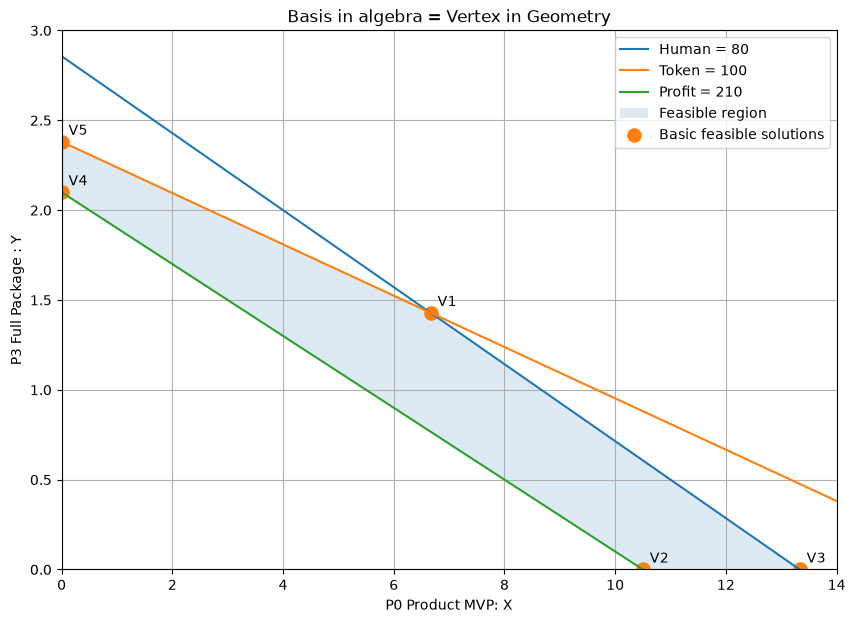

,Point,Basis,x_P0,y_P3
0,V1,"x_P0, y_P3, s_P",6.666667,1.428571
1,V2,"x_P0, s_H, s_T",10.500000,0.000000
2,V3,"x_P0, s_T, s_P",13.333333,0.000000
3,V4,"y_P3, s_H, s_T",0.000000,2.100000
4,V5,"y_P3, s_H, s_P",0.000000,2.380952


### 여기가 STEP 2의 핵심 장면이다.

대수적으로는: **BASIS를 선택**했다.

None


### 기하학적으로는 : **Feasible Polygon의 Vertex를 선택**한 것이다.

Simplex가 Basis를 바꾸며 이동한다는 말은 결국: **꼭짓점에서 인접 꼭짓점으로 이동한다**라는 뜻이다.

None


In [46]:
# 같은 (x,y)가 중복될 수 있으므로, 좌표 기준으로는 하나씩만 남긴다.

plot_bfs = (
    oringinal_bfs_df
    .drop_duplicates(
        subset=["x_P0", "y_P3"]
    )
    .reset_index(drop=True)
)

plot_bfs["Point"] = [
    f"V{i+1}"
    for i in range(len(plot_bfs)) # 각 점에 p1 p2 등 식별자를 붙인다.
]

points = plot_bfs[
    ["x_P0", "y_P3"]
# polygon을 그리기 위해 좌표를 배열로 만든다.
].to_numpy()

#centroid의 중심점 : 
centroid = points.mean(axis=0)

#중심기준 각도의 계산 : 
angles = np.arctan2(
    points[:, 1] - centroid[1],
    points[:, 0] - centroid[0],
)

order = np.argsort(angles)

polygon = points[order]

# -------------------------------------------
# constraint boundary
# -------------------------------------------

x_plot = np.linspace(
    0,
    14,
    500
)

human_line = (
    HUMAN_CAP
    - 6 * x_plot
) / 28

token_line = (
    TOKEN_CAP
    - 6 * x_plot
) / 42

profit_line = (
    PROFIT_TARGET
    - 20 * x_plot
) / 100

plt.figure(figsize=(10, 7))

plt.plot(
    x_plot,
    human_line,
    label="Human = 80"
)

plt.plot(
    x_plot,
    token_line,
    label="Token = 100"
)

plt.plot(
    x_plot,
    profit_line,
    label="Profit = 210"
)

#feasible polygon 자체 : 
plt.fill(
    polygon[:, 0],
    polygon[:, 1],
    alpha = 0.15,
    label = "Feasible region"
)

# BFS를 꼭짓점으로 찍는다.
plt.scatter(
    plot_bfs["x_P0"],
    plot_bfs["y_P3"],
    s = 90,
    label = "Basic feasible solutions"

)

# 각 vertex에 이름 표시.

for _, row in plot_bfs.iterrows():
    plt.annotate(
        row["Point"],
        (
            row["x_P0"],
            row["y_P3"],
        ),
        xytext = (5, 5),
        textcoords = "offset points",
    )

plt.xlabel("P0 Product MVP: X")
plt.ylabel("P3 Full Package : Y")

plt.title(
    "Basis in algebra = Vertex in Geometry"
)

plt.xlim(0, 14)
plt.ylim(0, 3)

plt.grid(True)
plt.legend()
plt.show()


##어떤 v가 basis인지 ?

display(
    plot_bfs[
        [
            "Point",
            "Basis",
            "x_P0",
            "y_P3",
        ]
    ]
)

print(md("여기가 STEP 2의 핵심 장면이다.", "대수적으로는: **BASIS를 선택**했다."))
print(md("기하학적으로는 : **Feasible Polygon의 Vertex를 선택**한 것이다.", "Simplex가 Basis를 바꾸며 이동한다는 말은 결국: **꼭짓점에서 인접 꼭짓점으로 이동한다**라는 뜻이다."))

# 2-7. Basis를 Linear Combination으로 읽기

예를 들어 다음 Basis를 고르자.

$$
B=
[A_x,A_y,A_{s_P}]
$$

그러면

$$
Bx_B=b
$$

는

$$
xA_x+yA_y+s_PA_{s_P}=b
$$

라는 뜻이다.

즉 Basis를 찾는다는 것은

> 선택한 세 개의 Column Vector를
> 어떤 coefficient로 섞으면
> target vector b를 만들 수 있는가?

를 묻는 것이다.

이것은 선형대수에서 배운 Linear Combination 문제와
완전히 동일하다.

In [50]:
chosen_basis_names = [
    "x_P0",
    "y_P3",
    "s_P",
]

chosen_idx = [
    variable_names.index(name)
    for name in chosen_basis_names
]

B = A[:, chosen_idx]

x_B = np.linalg.solve(
    B,
    b
)

print("Chosen Basis:")
print(chosen_basis_names)

print("\nB =")
print(B)

print("\nx_B =")
print(x_B)


# -------------------------------------------
# 각 column contribution 계산
# -------------------------------------------

components = []

for i in range(len(chosen_basis_names)):

    component = (
        x_B[i]
        * B[:, i]
    ) #coefficient * basis column

    components.append(
        component
    )

component_matrix = np.column_stack(
    components
)

component_df = pd.DataFrame(
    component_matrix,
    index=constraint_names,
    columns=[
        f"{name} contribution"
        for name in chosen_basis_names
    ],
)

component_df["Sum"] = (
    component_matrix.sum(axis=1)
)

component_df["Target b"] = b

display(component_df)

print(md("수학적으로 : $$xA_x+yA_y+s_PA_{s_P}=b$$", "코드에서는 component_matrix.sum(axis=1)이 정확히 그 선형결합을 수행한다. "))

Chosen Basis:
['x_P0', 'y_P3', 's_P']

B =
[[  6.  28.   0.]
 [  6.  42.   0.]
 [ 20. 100.  -1.]]

x_B =
[ 6.66666667  1.42857143 66.19047619]


,x_P0 contribution,y_P3 contribution,s_P contribution,Sum,Target b
Human,40.000000,40.000000,0.000000,80.0,80.0
Token,40.000000,60.000000,0.000000,100.0,100.0
Profit,133.333333,142.857143,-66.190476,210.0,210.0


### 수학적으로 : $$xA_x+yA_y+s_PA_{s_P}=b$$

코드에서는 component_matrix.sum(axis=1)이 정확히 그 선형결합을 수행한다. 

None


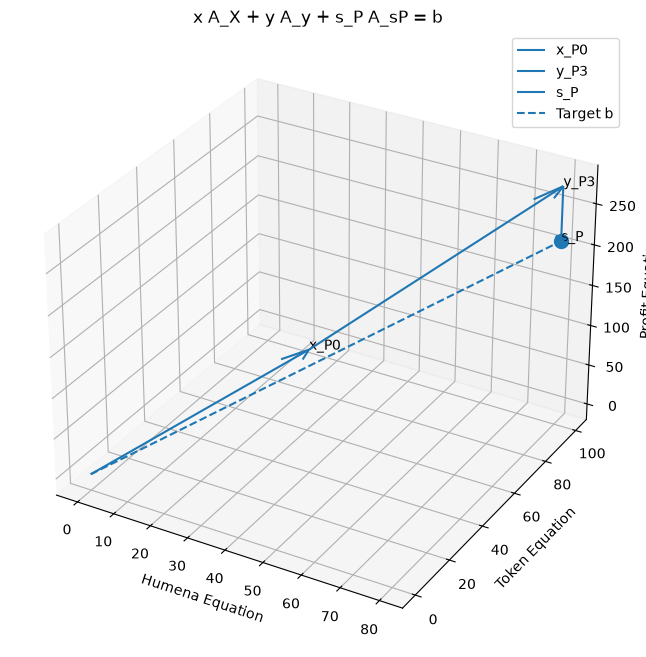

Chosen Basis:
['x_P0', 'y_P3', 's_P']

B =
[[  6.  28.   0.]
 [  6.  42.   0.]
 [ 20. 100.  -1.]]

x_B =
[ 6.66666667  1.42857143 66.19047619]


,x_P0 contribution,y_P3 contribution,s_P contribution,Sum,Target b
Human,40.000000,40.000000,0.000000,80.0,80.0
Token,40.000000,60.000000,0.000000,100.0,100.0
Profit,133.333333,142.857143,-66.190476,210.0,210.0


### 한 벡터만 그리는 게 아니라: $$xA_x$$ 만큼 이동하고 그 끝에서 $$yA_y$$ 만큼 이동하고 또 $$s_PA_{s_P}$$ 만큼 이동하여 최종적으로 $$b$$에 도달한다. 

벡터 덧셈을**이동을 이어 붙이는 것**으로 읽었던 선형대수학과 바로 연결된다. 

None


In [55]:
# Column Linear Combination의 3D 시각화

fig = plt.figure(figsize=(9,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

current = np.zeros(3)#첫번쨰 벡터는 원점에서 시작한다.

for name, component in zip(
    chosen_basis_names,
    components,
):
    next_point = (
        current
        + component
    )

    #current에서 component만큼 이동하도록
    ax.quiver(
        current[0],
        current[1],
        current[2],

        component[0],
        component[1],
        component[2],

        arrow_length_ratio = 0.08,
        label=name,
    )
    current = next_point
    
    ax.text(
        current[0],
        current[1],
        current[2],
        name,
    )

#targetB를 원점에서 직접 이어서 표시한다. 
ax.plot(
    [0, b[0]],
    [0, b[1]],
    [0, b[2]],
    linestyle="--",
    label="Target b",
)

ax.scatter(
    b[0],
    b[1],
    b[2],
    s=100,
)


ax.set_xlabel("Humena Equation")
ax.set_ylabel("Token Equation")
ax.set_zlabel("Profit Equation")

ax.set_title(
    "x A_X + y A_y + s_P A_sP = b"
)

ax.legend()
plt.show()

chosen_basis_names = [
    "x_P0",
    "y_P3",
    "s_P",
]

chosen_idx = [
    variable_names.index(name)
    for name in chosen_basis_names
]

B = A[:, chosen_idx]

x_B = np.linalg.solve(
    B,
    b
)

print("Chosen Basis:")
print(chosen_basis_names)

print("\nB =")
print(B)

print("\nx_B =")
print(x_B)


# -------------------------------------------
# 각 column contribution 계산
# -------------------------------------------

components = []

for i in range(len(chosen_basis_names)):

    component = (
        x_B[i]
        * B[:, i]
    ) #coefficient * basis column

    components.append(
        component
    )

component_matrix = np.column_stack(
    components
)

component_df = pd.DataFrame(
    component_matrix,
    index=constraint_names,
    columns=[
        f"{name} contribution"
        for name in chosen_basis_names
    ],
)

component_df["Sum"] = (
    component_matrix.sum(axis=1)
)

component_df["Target b"] = b

display(component_df)

print(md("한 벡터만 그리는 게 아니라: $$xA_x$$ 만큼 이동하고 그 끝에서 $$yA_y$$ 만큼 이동하고 또 $$s_PA_{s_P}$$ 만큼 이동하여 최종적으로 $$b$$에 도달한다. ", "벡터 덧셈을**이동을 이어 붙이는 것**으로 읽었던 선형대수학과 바로 연결된다. "))

# STEP 2 Reconstruction

## 1. Slack

$$
a^\top x\le b
$$

이면

$$
a^\top x+s=b
$$

Slack은 남은 자원이다.

---

## 2. Surplus

$$
a^\top x\ge b
$$

이면

$$
a^\top x-s=b
$$

Surplus는 목표를 초과한 양이다.

---

## 3. Artificial Variable

Surplus를 뺀 것만으로 초기 Basis를 만들 수 없을 때

$$
a^\top x-s+a=b
$$

형태로 임시 Artificial Variable을 넣는다.

Artificial Variable은 현실의 변수가 아니다.

Phase I에서

$$
\min a
$$

하여 0으로 제거한다.

---

## 4. Basis

m개의 독립 equation이 있으면
A의 column 중 m개의 선형독립 column을 선택한다.

$$
B=[A_{j_1},...,A_{j_m}]
$$

---

## 5. Basic Solution

Nonbasic Variable을 0으로 두고

$$
Bx_B=b
$$

를 푼다.

$$
x_B=B^{-1}b
$$

---

## 6. Basic Feasible Solution

Basic Solution이 추가로

$$
x_B\ge0
$$

을 만족하면 BFS이다.

---

## 7. Geometry

2-variable LP에서는

$$
\boxed{
BFS \leftrightarrow Feasible Region의 Vertex
}
$$

이다.